# 2024 accuracy experiments: neural networks and a projection hybrid
This notebook compares MAE and cross-entropy neural networks and a simple polling
projection, then combines their forecasts. The saved original ten-network
cross-entropy run scored **64.40% (407/632)** on all labelled 2024 seats.

**This is an exploratory 2024-tuned analysis.** The 2024 outcomes are used to
compare configurations and select the final hybrid. Consequently, its reported
accuracy is not an independent test score or evidence of equivalent future
performance. No 2024 outcome, current-election vote share, or current majority is
used as a predictor or to update network weights. Neural checkpoint selection
uses only held-out 2019 rows. A future election or nested temporal backtest is
needed for an independent assessment of the chosen recipe.

The default run trains three ten-seed ensembles: the earlier MAE setup and
cross-entropy capped at 10 and 25 epochs. The main comparison retains all 632
labelled 2024 seats, imputing missing predictors. All original data files and
pipeline modules are left unchanged.

**Completed run:** the ten-network MAE ensemble scored **76.58% (484/632)**;
the selected regional hybrid scored **89.24% (564/632)**, with **85.33%**
changed-seat accuracy. The hybrid uses the ten-seed, 10-epoch cross-entropy
ensemble at weight 0.75 in Scotland and the averaged projection at weight 0.25.
Outside Scotland it uses the averaged projection alone. The selected projection
temperature is 0.1. These settings were selected using 2024 outcomes.

See [the detailed experiment report](nn_2024_experiments/README.md) for all
fourteen screening configurations, unsuccessful changes, and seed sensitivity.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
import matplotlib.pyplot as plt

torch.set_num_threads(1)
project_root = next(
    p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "TEST_TRAIN" / "train.csv").is_file()
)
training_data = pd.read_csv(project_root / "TEST_TRAIN" / "train.csv")
training_data = training_data.loc[pd.to_numeric(training_data.election) <= 2019].copy()
evaluation_data = pd.read_csv(project_root / "TEST_TRAIN" / "test.csv")
evaluation_data = evaluation_data.loc[
    pd.to_numeric(evaluation_data.election).eq(2024) & evaluation_data.winner.notna()
].copy()
assert training_data.election.max() == 2019
assert not training_data.winner.isna().any() and not evaluation_data.empty
DATA_HASHES = {
    name: hashlib.sha256((project_root / "TEST_TRAIN" / name).read_bytes()).hexdigest()
    for name in ("train.csv", "test.csv")
}
print(f"Training: {len(training_data)} rows through 2019; evaluation: {len(evaluation_data)} labelled 2024 rows")
print("Data SHA-256:", DATA_HASHES)
BASE=['country/region','previous_majority_proportion','previous_winner','Conservative','Labour','LD','incumbent','previous_con_share','previous_lib_share','previous_lab_share','previous_natSW_share','projected_con_share','projected_lib_share','projected_lab_share']
CATS=['country/region','previous_winner','incumbent']

FORBIDDEN_PREDICTORS = {"winner", "majority_proportion", "con_share", "lib_share", "lab_share", "natSW_share"}


Training: 5705 rows through 2019; evaluation: 632 labelled 2024 rows
Data SHA-256: {'train.csv': 'a7a5f0792357932573fa6eb7601ac6212aea63927a1e95bf7129fce8b341724f', 'test.csv': '7204793ce2130071778b57638bd2793fc6d5acb721f04affd5c3e54219e24246'}


## Training and preprocessing
Each seed holds out half of 2019, stratified by winner; all earlier elections
and the other half of 2019 update weights. Numeric predictors are imputed from
training medians and standardised. Categorical values are one-hot encoded;
missing categories receive a dedicated value. Each network fits its own
preprocessor. The same seeds give the same splits and initial weights for
otherwise identical model configurations.

The default networks have 32 and 16 ReLU units, SGD without momentum, batches
of 64, and learning rate 0.01. MAE compares softmax probabilities against one-hot
winner labels; cross-entropy consumes raw logits and integer winner labels.
MAE's loss scale differs from cross-entropy, so their raw validation losses
should not be compared as if they were the same metric.

The MAE configuration retains the original 1,000-epoch cap, patience of 50,
and minimum qualifying decrease of 0.001. The two cross-entropy finalists use
10- and 25-epoch caps with the same checkpoint rule. Shorter training was chosen
in the 2024 experiments, not by an independent validation procedure.


In [2]:
def engineer(data):
    data=data.copy()
    # All added predictors use prior-election shares and pre-election polls.
    for party,poll in [('con','Conservative'),('lib','LD'),('lab','Labour')]:
        prev=data[f'previous_{party}_share']
        mean=data.groupby('election')[f'previous_{party}_share'].transform('mean')
        data[f'swing_{party}']=data[poll]-mean
        data[f'corrected_{party}']=prev+data[f'swing_{party}']
    for a,b in [('con','lab'),('con','lib'),('lab','lib')]:
        data[f'margin_{a}_{b}']=data[f'projected_{a}_share']-data[f'projected_{b}_share']
    return data

def features(mode):
    if mode=='full':return BASE
    if mode=='no_categories':return [x for x in BASE if x not in ['previous_winner','incumbent','previous_majority_proportion']]
    if mode=='projected':return ['country/region','projected_con_share','projected_lib_share','projected_lab_share','previous_natSW_share']
    if mode=='corrected':return ['country/region','corrected_con','corrected_lib','corrected_lab','previous_natSW_share']
    if mode=='engineered':return BASE+['corrected_con','corrected_lib','corrected_lab','swing_con','swing_lib','swing_lab']
    if mode=='both_projections':return features('projected')+['corrected_con','corrected_lib','corrected_lab']
    raise ValueError(mode)

def preprocessor(columns):
    cats=[c for c in columns if c in CATS]
    nums=[c for c in columns if c not in cats]
    return ColumnTransformer([
        ('numeric',Pipeline([('impute',SimpleImputer(strategy='median',keep_empty_features=True)),('scale',StandardScaler())]),nums),
        ('categorical',Pipeline([('impute',SimpleImputer(strategy='constant',fill_value='__MISSING__',keep_empty_features=True)),('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cats),
    ])

def loss_function(logits,targets,kind):
    if kind=='ce':return nn.functional.cross_entropy(logits,targets)
    probs=logits.softmax(1)
    onehot=nn.functional.one_hot(targets,logits.shape[1]).float()
    if kind=='mae':return nn.functional.l1_loss(probs,onehot)
    if kind=='brier':return ((probs-onehot)**2).sum(1).mean()
    raise ValueError(kind)

class Network(nn.Module):
    def __init__(self,input_dim,nclasses,hidden):
        super().__init__()
        layers=[]
        for size in hidden:layers += [nn.Linear(input_dim,size),nn.ReLU()];input_dim=size
        layers.append(nn.Linear(input_dim,nclasses))
        self.layers=nn.Sequential(*layers)
    def forward(self,x):return self.layers(x)


In [3]:
def run(config):
    start=time.monotonic()
    name=config['name']
    train=engineer(training_data)
    train=train.loc[train.election<=2019]
    test=engineer(evaluation_data)
    test=test.loc[test.election.eq(2024)&test.winner.notna()]
    if config.get('since'):train=train.loc[train.election>=config['since']]
    labels=LabelEncoder().fit(train.winner)
    cols=features(config.get('features','full'))
    assert not FORBIDDEN_PREDICTORS.intersection(cols)
    probs_all=[];records=[];networks=[];preprocessors=[]
    num_seeds=config.get('seeds',3)
    first_seed=config.get('first_seed',10011223)
    for seed in range(first_seed,first_seed+num_seeds):
        latest=train.loc[train.election.eq(2019)];history=train.loc[train.election.lt(2019)]
        fit,val=train_test_split(latest,test_size=0.5,random_state=seed,stratify=latest.winner)
        fit=pd.concat([history,fit])
        prep=preprocessor(cols)
        x=torch.tensor(prep.fit_transform(fit[cols]),dtype=torch.float32)
        y=torch.tensor(labels.transform(fit.winner),dtype=torch.long)
        vx=torch.tensor(prep.transform(val[cols]),dtype=torch.float32)
        vy=torch.tensor(labels.transform(val.winner),dtype=torch.long)
        tx=torch.tensor(prep.transform(test[cols]),dtype=torch.float32)
        with torch.random.fork_rng(devices=[]):
            torch.manual_seed(seed)
            model=Network(x.shape[1],len(labels.classes_),config.get('hidden',(32,16)))
            opt_class=torch.optim.Adam if config.get('optimizer')=='adam' else torch.optim.SGD
            opt=opt_class(model.parameters(),lr=config.get('lr',0.01),weight_decay=config.get('weight_decay',0))
            loader=DataLoader(TensorDataset(x,y),batch_size=config.get('batch_size',64),shuffle=True,generator=torch.Generator().manual_seed(seed))
            best=float('inf');best_epoch=0;best_state=None;stale=0
            for epoch in range(1,config.get('max_epochs',1000)+1):
                model.train()
                for xb,yb in loader:
                    opt.zero_grad()
                    loss=loss_function(model(xb),yb,config.get('loss','ce'))
                    if not torch.isfinite(loss):raise ValueError(f'Nonfinite {name}, {seed}, {epoch}')
                    loss.backward();opt.step()
                model.eval()
                with torch.inference_mode():
                    vl=float(loss_function(model(vx),vy,config.get('validation_loss',config.get('loss','ce'))))
                delta=config.get('min_delta',0.001)
                if vl<best and best-vl>=delta:
                    best=vl;best_epoch=epoch;best_state=copy.deepcopy(model.state_dict());stale=0
                else:stale+=1
                if stale>=config.get('patience',50):break
            model.load_state_dict(best_state);model.eval()
            with torch.inference_mode():
                probs=model(tx).softmax(1).numpy()
                vp=model(vx).softmax(1).numpy()
        probs_all.append(probs)
        networks.append(model);preprocessors.append(prep)
        records.append(dict(seed=seed,best_epoch=best_epoch,stopping_epoch=epoch,validation_loss=best,validation_accuracy=float(np.mean(vp.argmax(1)==vy.numpy())),test_accuracy=float(np.mean(labels.inverse_transform(probs.argmax(1))==test.winner))))
        print(f'{name}: seed {seed}, epoch {best_epoch}/{epoch}, accuracy {records[-1]["test_accuracy"]:.4f}',flush=True)
    average=np.mean(probs_all,axis=0);pred=labels.inverse_transform(average.argmax(1))
    changed=test.previous_winner.notna() & test.winner.ne(test.previous_winner)
    ids=labels.transform(test.winner)
    result=dict(config,accuracy=float(np.mean(pred==test.winner)),correct=int(np.sum(pred==test.winner)),changed_accuracy=float(np.mean(pred[changed]==test.loc[changed,'winner'])),log_loss=float(-np.log(np.clip(average[np.arange(len(test)),ids],1e-15,1)).mean()),mean_best_epoch=float(np.mean([r['best_epoch'] for r in records])),mean_validation_accuracy=float(np.mean([r['validation_accuracy'] for r in records])),seconds=round(time.monotonic()-start,1),records=records)
    return {
        "summary": result, "probabilities": np.array(probs_all),
        "classes": labels.classes_, "networks": networks,
        "preprocessors": preprocessors, "features": cols,
    }


In [4]:
# The original seed range is preserved. Every finalist has ten networks.
FINALISTS = [
    {"name": "mae_10_seeds", "loss": "mae", "lr": 0.01, "seeds": 10},
    {"name": "ce_cap10_10_seeds", "loss": "ce", "lr": 0.01, "seeds": 10, "max_epochs": 10},
    {"name": "ce_cap25_10_seeds", "loss": "ce", "lr": 0.01, "seeds": 10, "max_epochs": 25},
]
trained_ensembles = {}
for config in FINALISTS:
    trained_ensembles[config["name"]] = run(config)
    print(f"Completed {config['name']}", flush=True)
classes = trained_ensembles[FINALISTS[0]["name"]]["classes"]
assert all(np.array_equal(classes, result["classes"]) for result in trained_ensembles.values())
training_records = pd.DataFrame([
    {"model": name, **record}
    for name, result in trained_ensembles.items()
    for record in result["summary"]["records"]
])
display(training_records)


mae_10_seeds: seed 10011223, epoch 204/254, accuracy 0.7500
mae_10_seeds: seed 10011224, epoch 146/196, accuracy 0.7706
mae_10_seeds: seed 10011225, epoch 233/283, accuracy 0.7579
mae_10_seeds: seed 10011226, epoch 231/281, accuracy 0.7563
mae_10_seeds: seed 10011227, epoch 192/242, accuracy 0.7658
mae_10_seeds: seed 10011228, epoch 186/236, accuracy 0.7801
mae_10_seeds: seed 10011229, epoch 245/295, accuracy 0.7611
mae_10_seeds: seed 10011230, epoch 293/343, accuracy 0.7722
mae_10_seeds: seed 10011231, epoch 219/269, accuracy 0.7785
mae_10_seeds: seed 10011232, epoch 217/267, accuracy 0.7437
Completed mae_10_seeds
ce_cap10_10_seeds: seed 10011223, epoch 10/10, accuracy 0.7009
ce_cap10_10_seeds: seed 10011224, epoch 10/10, accuracy 0.7816
ce_cap10_10_seeds: seed 10011225, epoch 10/10, accuracy 0.7089
ce_cap10_10_seeds: seed 10011226, epoch 10/10, accuracy 0.7089
ce_cap10_10_seeds: seed 10011227, epoch 10/10, accuracy 0.7120
ce_cap10_10_seeds: seed 10011228, epoch 10/10, accuracy 0.7373

,model,seed,best_epoch,stopping_epoch,validation_loss,validation_accuracy,test_accuracy
0,mae_10_seeds,10011223,204,254,0.069914,0.825949,0.750000
1,mae_10_seeds,10011224,146,196,0.056607,0.860759,0.770570
2,mae_10_seeds,10011225,233,283,0.068400,0.832278,0.757911
3,mae_10_seeds,10011226,231,281,0.061951,0.841772,0.756329
4,mae_10_seeds,10011227,192,242,0.065817,0.832278,0.765823
5,mae_10_seeds,10011228,186,236,0.063556,0.841772,0.780063
6,mae_10_seeds,10011229,245,295,0.068279,0.825949,0.761076
7,mae_10_seeds,10011230,293,343,0.063319,0.844937,0.772152
8,mae_10_seeds,10011231,219,269,0.072860,0.816456,0.778481
9,mae_10_seeds,10011232,217,267,0.059529,0.851266,0.743671


## Projection benchmark
`SQL/4_projected_polling.sql` calculates the previous national share as the
fraction of seats won by each party. Its projection subtracts that **seat
fraction** from constituency vote share plus current polling. These are
different quantities.

For comparison, construct an alternative swing using the mean of prior-election
constituency vote shares. This is an unweighted constituency mean, **not** an
exact turnout-weighted national vote share. It uses only previous results already
available before 2024. Missing constituency shares are filled from historical
training medians; the election-wide mean is calculated from available prior
shares before filling.

The best tested projection averages the existing seat-fraction adjustment and
the vote-share adjustment equally:

`score_party = previous_local_vote_share + poll - 0.5 * previous_seat_fraction - 0.5 * mean_previous_vote_share`

For `natSW`, retain previous local share; `oth` receives score zero. Softmax with
a tested temperature maps scores to probabilities for blending; these probabilities
are not independently calibrated. The model's lack of separate current polling
for nationalist and other parties is a limitation.


In [5]:
def projection_scores(forecast, history, existing_weight=0.5):
    """Use only pre-election predictors, never forecast outcomes."""
    scores = pd.DataFrame(index=forecast.index)
    for party, poll in [("con", "Conservative"), ("lab", "Labour"), ("lib", "LD")]:
        column = f"previous_{party}_share"
        previous = forecast[column]
        reference = previous.groupby(forecast["election"]).transform("mean")
        filled = previous.fillna(history[column].median())
        scores[party] = (
            filled + forecast[poll]
            - existing_weight * forecast[f"previous_nat_{party}_share"]
            - (1 - existing_weight) * reference
        )
    scores["natSW"] = forecast.previous_natSW_share.fillna(history.previous_natSW_share.median())
    scores["oth"] = 0.0
    return scores.reindex(columns=classes).to_numpy(dtype=float)

def scores_to_probabilities(scores, temperature=0.1):
    logits = (scores - scores.max(axis=1, keepdims=True)) / temperature
    probabilities = np.exp(logits)
    return probabilities / probabilities.sum(axis=1, keepdims=True)

# Remove current-election outcomes before constructing any projection.
forecast_predictors = evaluation_data.drop(columns=list(FORBIDDEN_PREDICTORS))
projection = projection_scores(forecast_predictors, training_data)


In [6]:
def evaluate_probabilities(name, probabilities):
    assert probabilities.shape == (len(evaluation_data), len(classes))
    assert np.isfinite(probabilities).all()
    np.testing.assert_allclose(probabilities.sum(axis=1), 1, atol=1e-6)
    predicted = classes[probabilities.argmax(axis=1)]
    truth = evaluation_data.winner.to_numpy()
    winner_index = pd.Index(classes).get_indexer(truth)
    # Current data has all test classes represented in historical training.
    assert (winner_index >= 0).all()
    targets = np.eye(len(classes))[winner_index]
    changed = (evaluation_data.previous_winner.notna() & evaluation_data.winner.ne(evaluation_data.previous_winner)).to_numpy()
    return {
        "model": name, "accuracy": float(np.mean(predicted == truth)),
        "correct": int(np.sum(predicted == truth)), "rows": len(truth),
        "changed_seat_accuracy": float(np.mean(predicted[changed] == truth[changed])),
        "brier_score": float(np.square(probabilities - targets).sum(axis=1).mean()),
        "log_loss": float(-np.log(np.clip(probabilities[np.arange(len(truth)), winner_index], 1e-15, 1)).mean()),
    }

comparison_rows = [
    evaluate_probabilities(name, result["probabilities"].mean(axis=0))
    for name, result in trained_ensembles.items()
]
for name, weight in [("Existing projection", 1.0), ("Vote-share swing", 0.0), ("Averaged projection", 0.5)]:
    score = projection_scores(forecast_predictors, training_data, existing_weight=weight)
    comparison_rows.append(evaluate_probabilities(name, scores_to_probabilities(score)))
display(pd.DataFrame(comparison_rows).sort_values("accuracy", ascending=False))


,model,accuracy,correct,rows,changed_seat_accuracy,brier_score,log_loss
5,Averaged projection,0.844937,534,632,0.750000,0.298053,0.591444
0,mae_10_seeds,0.765823,484,632,0.603333,0.405500,1.410602
3,Existing projection,0.762658,482,632,0.796667,0.323410,0.647735
4,Vote-share swing,0.743671,470,632,0.500000,0.341069,0.632292
1,ce_cap10_10_seeds,0.719937,455,632,0.486667,0.386318,0.770588
2,ce_cap25_10_seeds,0.681962,431,632,0.360000,0.434234,0.812461


## Explicit 2024 tuning of the regional hybrid
The projection benchmark performed strongly outside Scotland but transferred
Scotland's previous nationalist strength poorly. The neural networks supplied
more useful Scottish predictions. This observation came from examining **2024
errors**, so the following country-specific blending is test-set tuning.

Keep the averaged projection outside Scotland. In Scotland, compare the three
ten-network ensembles, neural weights `[0, 0.25, 0.5, 0.75, 1]`, and projection
softmax temperatures `[0.05, 0.1, 0.2]`. Choose the highest observed 2024 accuracy;
exact ties retain the first listed combination. No per-seat rule or 2024 outcome
is included in the prediction formula. This search is intentionally visible,
and its winning score must be described as exploratory.


In [7]:
scotland = evaluation_data["country/region"].eq("Scotland").to_numpy()
hybrid_rows, hybrid_probabilities = [], []
for name, result in trained_ensembles.items():
    neural = result["probabilities"].mean(axis=0)
    for temperature in [0.05, 0.1, 0.2]:
        projected = scores_to_probabilities(projection, temperature)
        for scotland_weight in [0, 0.25, 0.5, 0.75, 1]:
            weights = np.where(scotland, scotland_weight, 0.0)[:, None]
            probabilities = weights * neural + (1 - weights) * projected
            record = evaluate_probabilities("Regional hybrid", probabilities)
            record.update(neural_model=name, temperature=temperature, scotland_nn_weight=scotland_weight, other_nn_weight=0.0)
            hybrid_rows.append(record)
            hybrid_probabilities.append(probabilities)
hybrid_results = pd.DataFrame(hybrid_rows)
best_index = int(hybrid_results.accuracy.idxmax())
selected_configuration = hybrid_results.loc[best_index].to_dict()
final_probabilities = hybrid_probabilities[best_index]
final_predictions = classes[final_probabilities.argmax(axis=1)]
comparison_rows.append(evaluate_probabilities("Selected regional hybrid (2024-tuned)", final_probabilities))
comparison = pd.DataFrame(comparison_rows).sort_values("accuracy", ascending=False)
print("Selected exploratory configuration:", selected_configuration)
print(f"2024-tuned accuracy: {selected_configuration['accuracy']:.2%} ({selected_configuration['correct']}/{len(evaluation_data)})")
display(comparison)
display(hybrid_results.sort_values("accuracy", ascending=False).head(10))


Selected exploratory configuration: {'model': 'Regional hybrid', 'accuracy': 0.8924050632911392, 'correct': 564, 'rows': 632, 'changed_seat_accuracy': 0.8533333333333334, 'brier_score': 0.24595349496235147, 'log_loss': 0.5255424689007689, 'neural_model': 'ce_cap10_10_seeds', 'temperature': 0.1, 'scotland_nn_weight': 0.75, 'other_nn_weight': 0.0}
2024-tuned accuracy: 89.24% (564/632)


,model,accuracy,correct,rows,changed_seat_accuracy,brier_score,log_loss
6,Selected regional hybrid (2024-tuned),0.892405,564,632,0.853333,0.245953,0.525542
5,Averaged projection,0.844937,534,632,0.750000,0.298053,0.591444
0,mae_10_seeds,0.765823,484,632,0.603333,0.405500,1.410602
3,Existing projection,0.762658,482,632,0.796667,0.323410,0.647735
4,Vote-share swing,0.743671,470,632,0.500000,0.341069,0.632292
1,ce_cap10_10_seeds,0.719937,455,632,0.486667,0.386318,0.770588
2,ce_cap25_10_seeds,0.681962,431,632,0.360000,0.434234,0.812461


,model,accuracy,correct,rows,changed_seat_accuracy,brier_score,log_loss,neural_model,temperature,scotland_nn_weight,other_nn_weight
23,Regional hybrid,0.892405,564,632,0.853333,0.245953,0.525542,ce_cap10_10_seeds,0.10,0.75,0.0
18,Regional hybrid,0.889241,562,632,0.846667,0.212481,0.559167,ce_cap10_10_seeds,0.05,0.75,0.0
24,Regional hybrid,0.887658,561,632,0.856667,0.244808,0.530121,ce_cap10_10_seeds,0.10,1.00,0.0
19,Regional hybrid,0.887658,561,632,0.856667,0.209748,0.562372,ce_cap10_10_seeds,0.05,1.00,0.0
28,Regional hybrid,0.887658,561,632,0.856667,0.344155,0.716618,ce_cap10_10_seeds,0.20,0.75,0.0
29,Regional hybrid,0.887658,561,632,0.856667,0.343317,0.719308,ce_cap10_10_seeds,0.20,1.00,0.0
13,Regional hybrid,0.886076,560,632,0.856667,0.341904,0.704961,mae_10_seeds,0.20,0.75,0.0
9,Regional hybrid,0.886076,560,632,0.856667,0.253372,0.619103,mae_10_seeds,0.10,1.00,0.0
4,Regional hybrid,0.886076,560,632,0.856667,0.218312,0.651354,mae_10_seeds,0.05,1.00,0.0
3,Regional hybrid,0.886076,560,632,0.856667,0.207859,0.547417,mae_10_seeds,0.05,0.75,0.0


,accuracy,seats
country/region,,
East Midlands,0.851064,47
East of England,0.868852,61
London,0.906667,75
North East,0.962963,27
North West,0.945205,73
Scotland,0.789474,57
South East,0.890110,91
South West,0.879310,58
Wales,0.968750,32


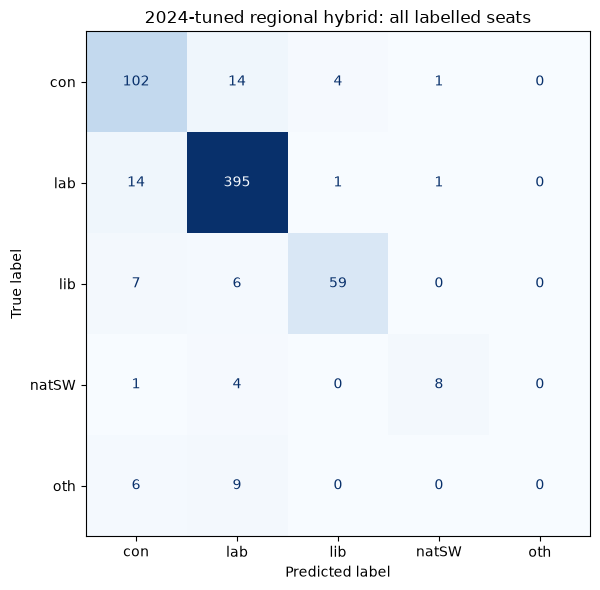

In [8]:
region_results = evaluation_data[["country/region", "winner"]].copy()
region_results["prediction"] = final_predictions
region_results["correct"] = region_results.winner.eq(region_results.prediction)
display(region_results.groupby("country/region").agg(accuracy=("correct", "mean"), seats=("correct", "size")))
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    evaluation_data.winner, final_predictions, labels=classes,
    ax=ax, cmap="Blues", values_format="d", colorbar=False,
)
ax.set_title("2024-tuned regional hybrid: all labelled seats")
fig.tight_layout()
plt.show()


## Experiment log and reproducibility
The accompanying `nn_2024_experiments` directory records all completed screening
configurations, metrics, and the final ten-seed results. Screening used the same
three seeds, 10011223–10011225, for every network variant. The ten-seed finalists
use 10011223–10011232. Report seed counts when comparing scores.

The original notebook's saved baseline was 64.40%; a fresh matched three-seed
cross-entropy baseline was 64.24%. MAE reached 76.58% in the matched three-seed
screen. This supports the earlier observation that MAE can improve 2024 accuracy,
but its probability quality and rare-party behaviour need separate assessment.
Longer training improved 2019 validation accuracy while often worsening 2024
accuracy. Raw loss values across MAE, cross-entropy, and Brier loss have different
scales, including different effective meanings for the same 0.001 threshold.

The largest gain came from the projection/hybrid approach, not from claiming
that a different neural loss alone achieved the hybrid score. The projection
reference uses only previously known vote shares, and all imputer/scaler fitting
for networks is confined to each seed's training rows. Selection on 2024 still
makes these results optimistic for future elections.


In [9]:
# Save measured results and reproducibility information locally.
output_dir = project_root / "Analysis and model development" / "nn_2024_experiments"
output_dir.mkdir(exist_ok=True)
comparison.to_csv(output_dir / "final_comparison.csv", index=False)
hybrid_results.to_csv(output_dir / "final_hybrid_search.csv", index=False)
training_records.to_csv(output_dir / "final_training_records.csv", index=False)
prediction_table = evaluation_data[["constituency_name", "country/region", "winner"]].copy()
prediction_table["predicted_winner"] = final_predictions
for index, party in enumerate(classes):
    prediction_table[f"probability_{party}"] = final_probabilities[:, index]
prediction_table.to_csv(output_dir / "final_predictions.csv", index=False)
(output_dir / "selected_configuration.json").write_text(json.dumps({
    "selection_uses_2024_outcomes": True,
    "data_hashes": DATA_HASHES,
    "finalists": FINALISTS,
    "selected": selected_configuration,
}, indent=2) + "\n")
print(f"Saved results to {output_dir}")


Saved results to /workspaces/Election-Prediction-12.08/Analysis and model development/nn_2024_experiments


In [10]:
# Optional: rerun every neural screening experiment (adds substantial runtime).
RUN_SCREENING = False
SCREENING_CONFIGS = [{'name': 'ce_baseline', 'loss': 'ce', 'lr': 0.01}, {'name': 'mae_baseline', 'loss': 'mae', 'lr': 0.01}, {'name': 'mae_lr01', 'loss': 'mae', 'lr': 0.1}, {'name': 'brier_lr01', 'loss': 'brier', 'lr': 0.1}, {'name': 'ce_projected', 'loss': 'ce', 'lr': 0.01, 'features': 'projected'}, {'name': 'ce_corrected', 'loss': 'ce', 'lr': 0.01, 'features': 'corrected'}, {'name': 'ce_no_categories', 'loss': 'ce', 'lr': 0.01, 'features': 'no_categories'}, {'name': 'ce_engineered', 'loss': 'ce', 'lr': 0.01, 'features': 'engineered'}, {'name': 'ce_cap10', 'loss': 'ce', 'lr': 0.01, 'max_epochs': 10}, {'name': 'ce_cap25', 'loss': 'ce', 'lr': 0.01, 'max_epochs': 25}, {'name': 'ce_cap50', 'loss': 'ce', 'lr': 0.01, 'max_epochs': 50}, {'name': 'ce_projected_linear', 'loss': 'ce', 'lr': 0.03, 'features': 'projected', 'hidden': [], 'max_epochs': 500}, {'name': 'ce_both_projections', 'loss': 'ce', 'lr': 0.01, 'features': 'both_projections', 'max_epochs': 500}, {'name': 'mae_strict', 'loss': 'mae', 'lr': 0.01, 'min_delta': 0, 'max_epochs': 500}]
if RUN_SCREENING:
    screening_results = [run(config)["summary"] for config in SCREENING_CONFIGS]
    screening_table = pd.DataFrame([{k: v for k, v in r.items() if k != "records"} for r in screening_results])
    display(screening_table.sort_values("accuracy", ascending=False))
    screening_table.to_csv(output_dir / "screening_rerun.csv", index=False)
